In [4]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from qwen_vl_utils import process_vision_info

# default: Load the model on the available device(s)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "/home/shang/Mirage/checkpoints/stage2_split", torch_dtype="auto", device_map="auto"
)

# We recommend enabling flash_attention_2 for better acceleration and memory saving, especially in multi-image and video scenarios.
# model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
#     "Qwen/Qwen2.5-VL-3B-Instruct",
#     torch_dtype=torch.bfloat16,
#     attn_implementation="flash_attention_2",
#     device_map="auto",
# )

# default processer
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct")
# processor = AutoProcessor.from_pretrained("/home/shang/Mirage/checkpoints/stage2_split")

# The default range for the number of visual tokens per image in the model is 4-16384.
# You can set min_pixels and max_pixels according to your needs, such as a token range of 256-1280, to balance performance and cost.
# min_pixels = 256*28*28
# max_pixels = 1280*28*28
# processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct", min_pixels=min_pixels, max_pixels=max_pixels)

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg",
            },
            {"type": "text", "text": "Describe this image."},
        ],
    }
]

# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cuda")

# Inference: Generation of the output
generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards: 100%|██████████| 4/4 [00:02<00:00,  1.81it/s]


["The image depicts a serene beach scene during what appears to be either sunrise or sunset, as indicated by the warm, golden light illuminating the sky and casting long shadows on the sand. A woman is sitting cross-legged on the sandy beach, smiling warmly at a light-colored dog, likely a Labrador Retriever, which is sitting in front of her. The dog is wearing a harness with colorful paw prints and is extending its paw towards the woman's hand, suggesting a playful interaction. The ocean waves can be seen in the background, adding to the tranquil atmosphere of the setting. The overall mood of the image is one of happiness and companions"]


Image dimensions: 256x256 pixels
Total pixels: 65536


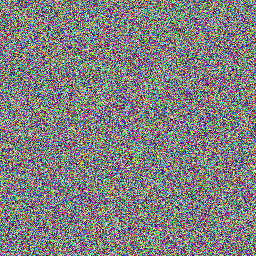

In [ ]:
from PIL import Image

# Load the image
img_path = "/home/shang/Mirage/data/vsp_spatial_planning/img/level_4/20/map_4x4_step_0.png"
img = Image.open(img_path)

# Get dimensions
width, height = img.size
print(f"Image dimensions: {width}x{height} pixels")
print(f"Total pixels: {width * height}")

# Create random noise with same dimensions as original image
import numpy as np


# Generate random noise array with values 0-255
noise_arr = np.random.randint(
    low=0, 
    high=256,
    size=(height, width, 3), 
    dtype=np.uint8
)

# Convert noise array to PIL Image
noise_img = Image.fromarray(noise_arr)

# Display the noisy image
display(noise_img)



In [5]:

for i in range(800):
    # Generate random noise array with values 0-255
    noise_arr = np.random.randint(
        low=0, 
        high=256,
        size=(height, width, 3), 
        dtype=np.uint8
    )

    # Convert noise array to PIL Image
    noise_img = Image.fromarray(noise_arr)
    noise_img.save(f"/home/shang/Mirage/data/noise_images/noise_{i}.png")

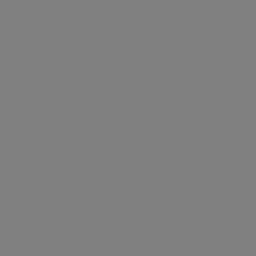

In [ ]:
from PIL import Image
gray_value = 128  # You can set this to any value between 0 (black) and 255 (white)
gray_arr = np.full((height, width, 3), gray_value, dtype=np.uint8)

# Convert gray array to PIL Image
gray_img = Image.fromarray(gray_arr)
gray_img.save("/home/shang/Mirage/data/img/gray.png")